Device: cpu


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]


Upload an image for analysis:


Saving CATIMAGE.jpg to CATIMAGE.jpg

Enter a question about the uploaded image: What animal is in the image?


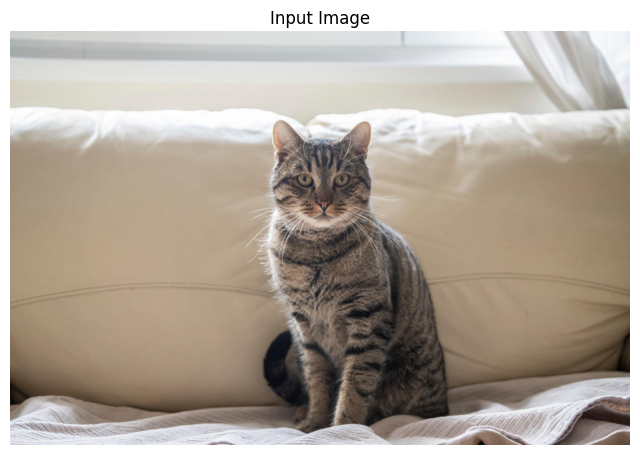


MULTIMODAL AI RESULT
--------------------------------------------------
Question: What animal is in the image?
Answer: cat


In [ ]:
!pip install transformers torch pillow matplotlib sentencepiece -q

import torch
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from transformers import BlipProcessor, BlipForQuestionAnswering

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load BLIP VQA model
model_name = "Salesforce/blip-vqa-base"

processor = BlipProcessor.from_pretrained(model_name)

model = BlipForQuestionAnswering.from_pretrained(
    model_name
).to(device)

# Upload an image
print("\nUpload an image for analysis:")
uploaded_files = files.upload()

image_path = next(iter(uploaded_files))

image = Image.open(image_path).convert("RGB")

# Get question from user
question = input(
    "\nEnter a question about the uploaded image: "
)

# Process image and question
inputs = processor(
    images=image,
    text=question,
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

# Generate answer
with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=30
    )

# Decode answer
answer = processor.decode(
    generated_ids[0],
    skip_special_tokens=True
)

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Display result
print("\nMULTIMODAL AI RESULT")
print("-" * 50)
print("Question:", question)
print("Answer:", answer)